<a href="https://colab.research.google.com/github/arun-arunisto/Tensorflow_Tutorial/blob/todo/ImageClassificationCNNTensorFlowAndKeras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Processing For CNN model

- Annotation Tool Used: [CVAT](https://www.cvat.ai/)
- Annotation file format: COCO V1.0

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

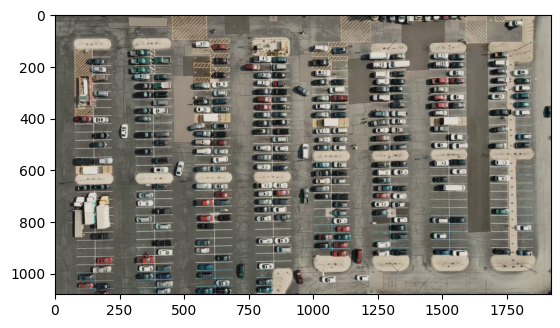

In [2]:
#loading the image
parking_image = cv2.imread("/content/drive/MyDrive/AbelFolder/parking_spot.png")
plt.imshow(parking_image[:, :, ::-1])

In [3]:
#loading the json file
import json


with open("/content/drive/MyDrive/data/parking_spot_data/instances_default.json") as f:
  data = json.load(f)

print(data)

{'licenses': [{'name': '', 'id': 0, 'url': ''}], 'info': {'contributor': '', 'date_created': '', 'description': '', 'url': '', 'version': '', 'year': ''}, 'categories': [{'id': 1, 'name': 'empty-space', 'supercategory': ''}, {'id': 2, 'name': 'non-empty-space', 'supercategory': ''}], 'images': [{'id': 1, 'width': 1920, 'height': 1080, 'file_name': 'parking_spot.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}], 'annotations': [{'id': 1, 'image_id': 1, 'category_id': 2, 'segmentation': [], 'area': 2612.210399999998, 'bbox': [288.97, 199.55, 82.98, 31.48], 'iscrowd': 0, 'attributes': {'occluded': False, 'rotation': 0.0}}, {'id': 2, 'image_id': 1, 'category_id': 2, 'segmentation': [], 'area': 2251.320900000001, 'bbox': [300.42, 233.89, 78.69, 28.61], 'iscrowd': 0, 'attributes': {'occluded': False, 'rotation': 0.0}}, {'id': 3, 'image_id': 1, 'category_id': 2, 'segmentation': [], 'area': 2306.618999999999, 'bbox': [307.57, 265.37, 70.11, 32.9], 'iscrowd': 0, 'attrib

In [4]:
#finding the keys
data.keys()

dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])

In [5]:
#finding the categories
data["categories"]

[{'id': 1, 'name': 'empty-space', 'supercategory': ''},
 {'id': 2, 'name': 'non-empty-space', 'supercategory': ''}]

So, based on the above categories:

- ***id 1:*** Empty Space
- ***id 2:*** Non Empty Space

In [6]:
#getting annotations structure
data["annotations"][0]

{'id': 1,
 'image_id': 1,
 'category_id': 2,
 'segmentation': [],
 'area': 2612.210399999998,
 'bbox': [288.97, 199.55, 82.98, 31.48],
 'iscrowd': 0,
 'attributes': {'occluded': False, 'rotation': 0.0}}

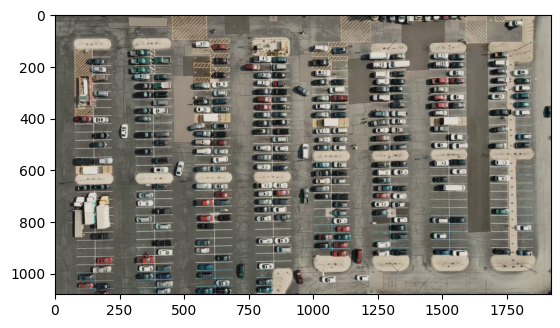

In [7]:
#drawing bounding box to the image using bbox data from annotations
parking_image_copy = parking_image.copy()
plt.imshow(parking_image_copy[:, :, ::-1])

In [8]:
#getting bbox values
bbox = data["annotations"][0]["bbox"]
bbox

[288.97, 199.55, 82.98, 31.48]

In [9]:
#allocating values to x, y, w, h cordinates
x, y, w, h = bbox

In [10]:
#getting the points
x_start, y_start = int(x), int(y)
x_end, y_end = int(x+w), int(y+h)

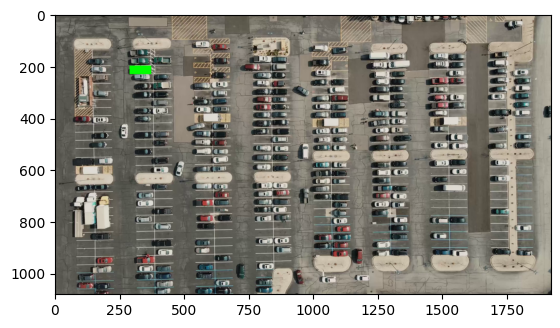

In [11]:
#drawing the bbox
cv2.rectangle(parking_image_copy, (x_start, y_start), (x_end, y_end), (0, 255, 0), cv2.FILLED)
plt.imshow(parking_image_copy[:, :, ::-1])

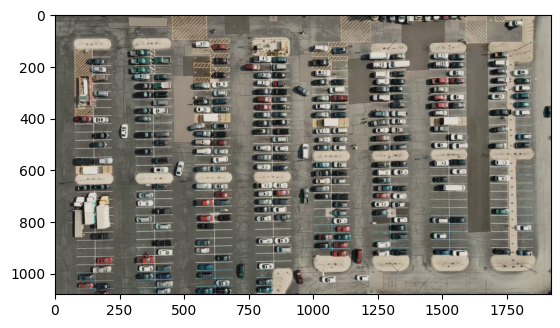

In [12]:
#marking image based categories
parking_img_2_copy = parking_image.copy()
plt.imshow(parking_img_2_copy[:, :, ::-1])

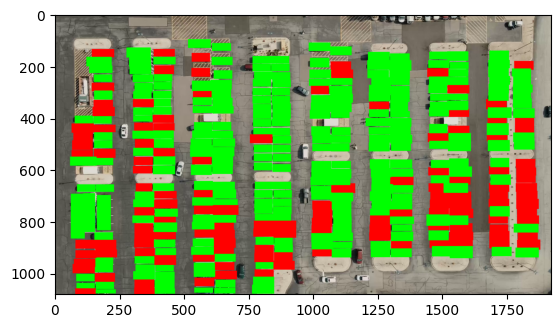

In [13]:
#looping through the annotations and marking the parking spots based on category
for i in data["annotations"]:
  #getting x, y, w, h
  x_, y_, w_, h_ = i["bbox"]
  if i["category_id"] == 1: #empty space red color
    cv2.rectangle(parking_img_2_copy, (int(x_), int(y_)), (int(x_+w_), int(y_+h_)), (0, 0, 255), cv2.FILLED)
  if i["category_id"] == 2: #non empty green color
    cv2.rectangle(parking_img_2_copy, (int(x_), int(y_)), (int(x_+w_), int(y_+h_)), (0, 255, 0), cv2.FILLED)

plt.imshow(parking_img_2_copy[:, :, ::-1])

In [16]:
#cropping the images and saving the images into cropped dataset folder based on the categories
empty = 0
non_empty = 0
for i in data["annotations"]:
  x1, y1, x2, y2 = i["bbox"]
  x1, y1, x2, y2 = int(x1), int(y1), int(x1+x2), int(y1+y2)
  if i["category_id"] == 1: #empty
    empty += 1
    empty_cropped_image = parking_image[y1:y2, x1:x2]
    cv2.imwrite(f"/content/cropped_dataset/empty/empty{empty}.jpg", empty_cropped_image)
  if i["category_id"] == 2: #non empty
    non_empty += 1
    non_empty_cropped_image = parking_image[y1:y2, x1:x2]
    cv2.imwrite(f"/content/cropped_dataset/nonempty/nonempty{non_empty}.jpg", non_empty_cropped_image)

print(f"Empty: {empty} Non-empty: {non_empty}")
print("Cropped Successfully!!")

Empty: 126 Non-empty: 266
Cropped Successfully!!


In [17]:
# using augmentation techniques and enlarging dataset without creating duplicates and saving into the folder augmented_dataset based on the category
import os

cropped_empty_dataset_path = "/content/cropped_dataset/empty"
cropped_non_empty_dataset_path = "/content/cropped_dataset/nonempty"

#list out the contents from directory
cropped_empty_dataset_contents = os.listdir(cropped_empty_dataset_path)
cropped_non_empty_dataset_contents = os.listdir(cropped_non_empty_dataset_path)

cropped_empty_dataset_contents

['empty38.jpg',
 'empty37.jpg',
 'empty26.jpg',
 'empty118.jpg',
 'empty99.jpg',
 'empty56.jpg',
 'empty116.jpg',
 'empty33.jpg',
 'empty58.jpg',
 'empty4.jpg',
 'empty71.jpg',
 'empty78.jpg',
 'empty101.jpg',
 'empty102.jpg',
 'empty63.jpg',
 'empty125.jpg',
 'empty29.jpg',
 'empty32.jpg',
 'empty6.jpg',
 'empty85.jpg',
 'empty31.jpg',
 'empty87.jpg',
 'empty66.jpg',
 'empty106.jpg',
 'empty94.jpg',
 'empty19.jpg',
 'empty98.jpg',
 'empty70.jpg',
 'empty124.jpg',
 'empty2.jpg',
 'empty84.jpg',
 'empty72.jpg',
 'empty55.jpg',
 'empty88.jpg',
 'empty57.jpg',
 'empty122.jpg',
 'empty60.jpg',
 'empty113.jpg',
 'empty21.jpg',
 'empty65.jpg',
 'empty7.jpg',
 'empty75.jpg',
 'empty5.jpg',
 'empty61.jpg',
 'empty59.jpg',
 'empty17.jpg',
 'empty105.jpg',
 'empty22.jpg',
 'empty24.jpg',
 'empty79.jpg',
 'empty20.jpg',
 'empty107.jpg',
 'empty74.jpg',
 'empty45.jpg',
 'empty18.jpg',
 'empty50.jpg',
 'empty3.jpg',
 'empty13.jpg',
 'empty86.jpg',
 'empty42.jpg',
 'empty95.jpg',
 'empty27.jpg',
 'e

In [18]:
# using TensorFlow ImageDatagenerator to create multiple images from single image by doing flip, rotation, scaling, zooming, etc
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
#defining the data augmentation params
data_gen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [20]:
#loading all the empty images (cropped) into a list
empty_bef_aug_list = []
for i in cropped_empty_dataset_contents:
  image = cv2.imread(f"/content/cropped_dataset/empty/{i}")
  empty_bef_aug_list.append(image)
empty_bef_aug_list

[array([[[ 75,  82,  79],
         [ 76,  82,  81],
         [ 78,  83,  84],
         ...,
         [143, 141, 107],
         [150, 148, 114],
         [154, 152, 117]],
 
        [[ 80,  87,  84],
         [ 75,  81,  80],
         [ 74,  79,  80],
         ...,
         [199, 194, 161],
         [200, 196, 161],
         [201, 197, 162]],
 
        [[ 80,  87,  84],
         [ 78,  84,  83],
         [ 74,  82,  82],
         ...,
         [136, 129,  96],
         [132, 126,  91],
         [130, 124,  87]],
 
        ...,
 
        [[ 84,  92,  92],
         [ 81,  89,  88],
         [ 79,  87,  86],
         ...,
         [ 77,  77,  65],
         [ 76,  75,  61],
         [ 74,  73,  59]],
 
        [[ 79,  88,  91],
         [ 77,  87,  87],
         [ 79,  87,  87],
         ...,
         [ 77,  78,  58],
         [ 78,  77,  56],
         [ 78,  78,  54]],
 
        [[ 78,  87,  90],
         [ 75,  84,  87],
         [ 79,  87,  87],
         ...,
         [161, 164, 138],
  

In [21]:
print(len(empty_bef_aug_list))

126


In [22]:
#loading all the non-empty images (cropped) into a list
non_empty_bef_aug_list = []
for i in cropped_non_empty_dataset_contents:
  image = cv2.imread(f"/content/cropped_dataset/nonempty/{i}")
  non_empty_bef_aug_list.append(image)
non_empty_bef_aug_list

[array([[[208, 217, 214],
         [206, 215, 212],
         [201, 210, 207],
         ...,
         [150, 160, 160],
         [149, 159, 159],
         [149, 159, 159]],
 
        [[111, 120, 117],
         [109, 118, 115],
         [136, 145, 142],
         ...,
         [109, 119, 119],
         [109, 119, 119],
         [109, 119, 119]],
 
        [[ 87,  95,  94],
         [ 87,  95,  94],
         [ 99, 108, 105],
         ...,
         [114, 124, 124],
         [114, 124, 124],
         [114, 124, 124]],
 
        ...,
 
        [[ 34,  34,  34],
         [ 23,  23,  23],
         [ 27,  27,  27],
         ...,
         [115, 127, 131],
         [117, 129, 133],
         [118, 130, 134]],
 
        [[ 37,  37,  37],
         [ 28,  28,  28],
         [ 32,  32,  32],
         ...,
         [112, 124, 128],
         [114, 126, 130],
         [115, 127, 131]],
 
        [[ 42,  44,  44],
         [ 37,  39,  39],
         [ 36,  38,  38],
         ...,
         [112, 124, 128],
  

In [23]:
print(len(non_empty_bef_aug_list))

266


In [24]:
#applying data augmentation and saving the images to augmented dataset
aug_empty_count = 0
for i in empty_bef_aug_list:
  for j in range(10):
    augmented_image = next(data_gen.flow(np.expand_dims(i, axis=0), batch_size=1))[0]
    aug_empty_count += 1
    cv2.imwrite(f"/content/augmented_dataset/empty/empty{aug_empty_count}.jpg", augmented_image)
print("Total Images:",aug_empty_count)

Total Images: 1260


In [25]:
aug_non_empty_count = 0
for i in non_empty_bef_aug_list:
  for j in range(10):
    augmented_image = next(data_gen.flow(np.expand_dims(i, axis=0), batch_size=1))[0]
    aug_non_empty_count += 1
    cv2.imwrite(f"/content/augmented_dataset/nonempty/nonempty{aug_non_empty_count}.jpg", augmented_image)
print("Total Images:",aug_non_empty_count)

Total Images: 2660


***The Last Step Of Image Processing***

Write a script to load the datase and generate batches for training (similar to the CIFAR-10 data loader).


In [26]:
#defining the dataset path and classes
#Augmented Dataset Path
aug_dataset_path = "/content/augmented_dataset"
classes = ["empty", "nonempty"]

In [27]:
img_height, img_width = 32, 32
batch_size = 32
split_ratio = 0.2 #80% for training and 20% for validation

In [28]:
#creating a ImageDataGenerator for training and validation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=split_ratio
)

In [29]:
# Training data generator (80% of the data)
train_generator = datagen.flow_from_directory(
    aug_dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use 'training' split
)

# Validation data generator (20% of the data)
validation_generator = datagen.flow_from_directory(
    aug_dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use 'validation' split
)

Found 3136 images belonging to 3 classes.
Found 784 images belonging to 3 classes.


## CNN Model Implementation using keras

In [30]:
#Building a model
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

## CNN Model Structure

<img src="https://learnopencv.com/wp-content/uploads/2023/01/tensorflow-keras-cnn-architecture.png"/>

In [38]:
def cnn_model(input_shape=(32, 32, 3)):

    model = Sequential()

    #------------------------------------
    # Conv Block 1: 32 Filters, MaxPool.
    #------------------------------------
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    #------------------------------------
    # Conv Block 2: 64 Filters, MaxPool.
    #------------------------------------
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    #------------------------------------
    # Conv Block 3: 64 Filters, MaxPool.
    #------------------------------------
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    #------------------------------------
    # Flatten the convolutional features.
    #------------------------------------
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))

    # Change the output layer to have 3 neurons (or the number of classes in your dataset)
    model.add(Dense(3, activation='softmax')) #This was changed from 10 to 3

    return model

In [39]:
#creating the model
model = cnn_model(input_shape=(32, 32, 3))
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 665,763 (2.54 MB)

 Trainable params: 665,763 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#compiling the model
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [41]:
#Training the model
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 286ms/step - accuracy: 0.6480 - loss: 0.6952 - val_accuracy: 0.9414 - val_loss: 0.1899
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8125 - val_loss: 0.3167
Epoch 3/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 240ms/step - accuracy: 0.9139 - loss: 0.2664 - val_accuracy: 0.9388 - val_loss: 0.1769
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9375 - val_loss: 0.1199
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 240ms/step - accuracy: 0.9392 - loss: 0.2024 - val_accuracy: 0.9323 - val_loss: 0.2010
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8125 - val_loss: 0.2957
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 234ms/step - accuracy: 0.9370 - loss: 0.1713 - val_accuracy: 0.9479 - val_loss: 0.1832
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9375 - val_loss: 0.1622
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step - accuracy: 0.9520 - loss: 0.1462 - val_accuracy: 0.9609 - val_loss: 0.1491
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+

In [46]:
# Evaluate the model on the validation data
loss, accuracy = model.evaluate(validation_generator)
print('Validation accuracy:', accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9489 - loss: 0.1884
Validation accuracy: 0.9617347121238708


In [47]:
# Get a batch of validation data
x_batch, y_batch = next(validation_generator)

# Make predictions on the batch
predictions = model.predict(x_batch)

# Get the predicted class for each image
predicted_classes = np.argmax(predictions, axis=1)

# Get the actual class for each image
actual_classes = np.argmax(y_batch, axis=1)

# Print the predicted and actual classes for the first 10 images
for i in range(10):
  print("Predicted class:", predicted_classes[i])
  print("Actual class:", actual_classes[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
Predicted class: 2
Actual class: 2
Predicted class: 1
Actual class: 1
Predicted class: 2
Actual class: 2
Predicted class: 2
Actual class: 2
Predicted class: 1
Actual class: 1
Predicted class: 2
Actual class: 2
Predicted class: 2
Actual class: 2
Predicted class: 2
Actual class: 2
Predicted class: 2
Actual class: 2
Predicted class: 2
Actual class: 2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


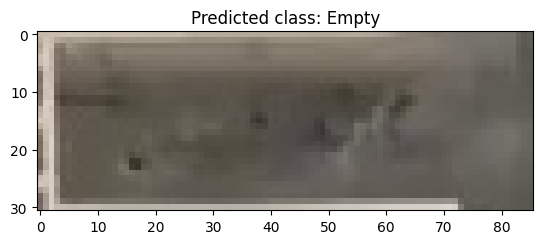

In [56]:
image_path = "/content/cropped_dataset/empty/empty1.jpg"  # Replace with your image path
img = cv2.imread(image_path)

# Preprocess the image
img = cv2.resize(img, (32, 32))  # Resize to match the model input size
img = img / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Make a prediction
prediction = model.predict(img)

# Get the predicted class
predicted_class = np.argmax(prediction)

classes = {1:"Empty", 2:"Non-Empty"}

# Display the image and the prediction
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted class: {classes[predicted_class]}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


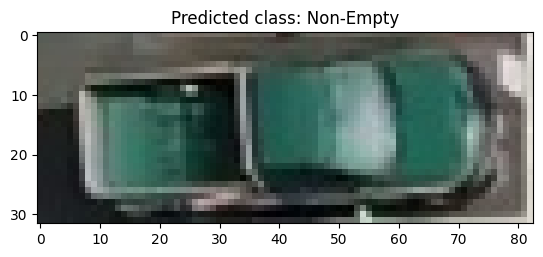

In [57]:
image_path = "/content/cropped_dataset/nonempty/nonempty1.jpg"  # Replace with your image path
img = cv2.imread(image_path)

# Preprocess the image
img = cv2.resize(img, (32, 32))  # Resize to match the model input size
img = img / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Make a prediction
prediction = model.predict(img)

# Get the predicted class
predicted_class = np.argmax(prediction)

classes = {1:"Empty", 2:"Non-Empty"}

# Display the image and the prediction
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted class: {classes[predicted_class]}")
plt.show()

In [59]:
#saving the model
model.save("/content/drive/MyDrive/data/parking_spot_data/parking_spot_cnn_model.keras")

In [60]:
#loading the model
from tensorflow.keras.models import load_model

trained_model = load_model("/content/drive/MyDrive/data/parking_spot_data/parking_spot_cnn_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


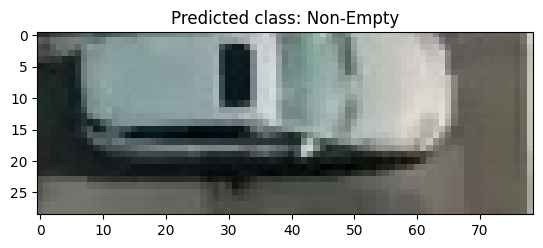

In [61]:
image_path = "/content/cropped_dataset/nonempty/nonempty2.jpg"  # Replace with your image path
img = cv2.imread(image_path)

# Preprocess the image
img = cv2.resize(img, (32, 32))  # Resize to match the model input size
img = img / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Make a prediction
prediction = trained_model.predict(img)

# Get the predicted class
predicted_class = np.argmax(prediction)

classes = {1:"Empty", 2:"Non-Empty"}

# Display the image and the prediction
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted class: {classes[predicted_class]}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


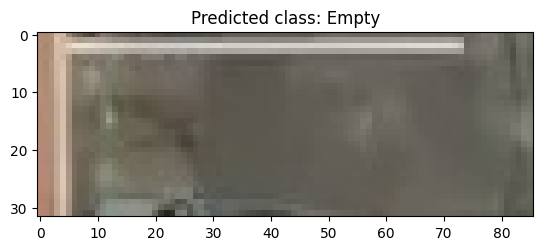

In [62]:
image_path = "/content/cropped_dataset/empty/empty2.jpg"  # Replace with your image path
img = cv2.imread(image_path)

# Preprocess the image
img = cv2.resize(img, (32, 32))  # Resize to match the model input size
img = img / 255.0  # Normalize pixel values
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Make a prediction
prediction = trained_model.predict(img)

# Get the predicted class
predicted_class = np.argmax(prediction)

classes = {1:"Empty", 2:"Non-Empty"}

# Display the image and the prediction
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted class: {classes[predicted_class]}")
plt.show()